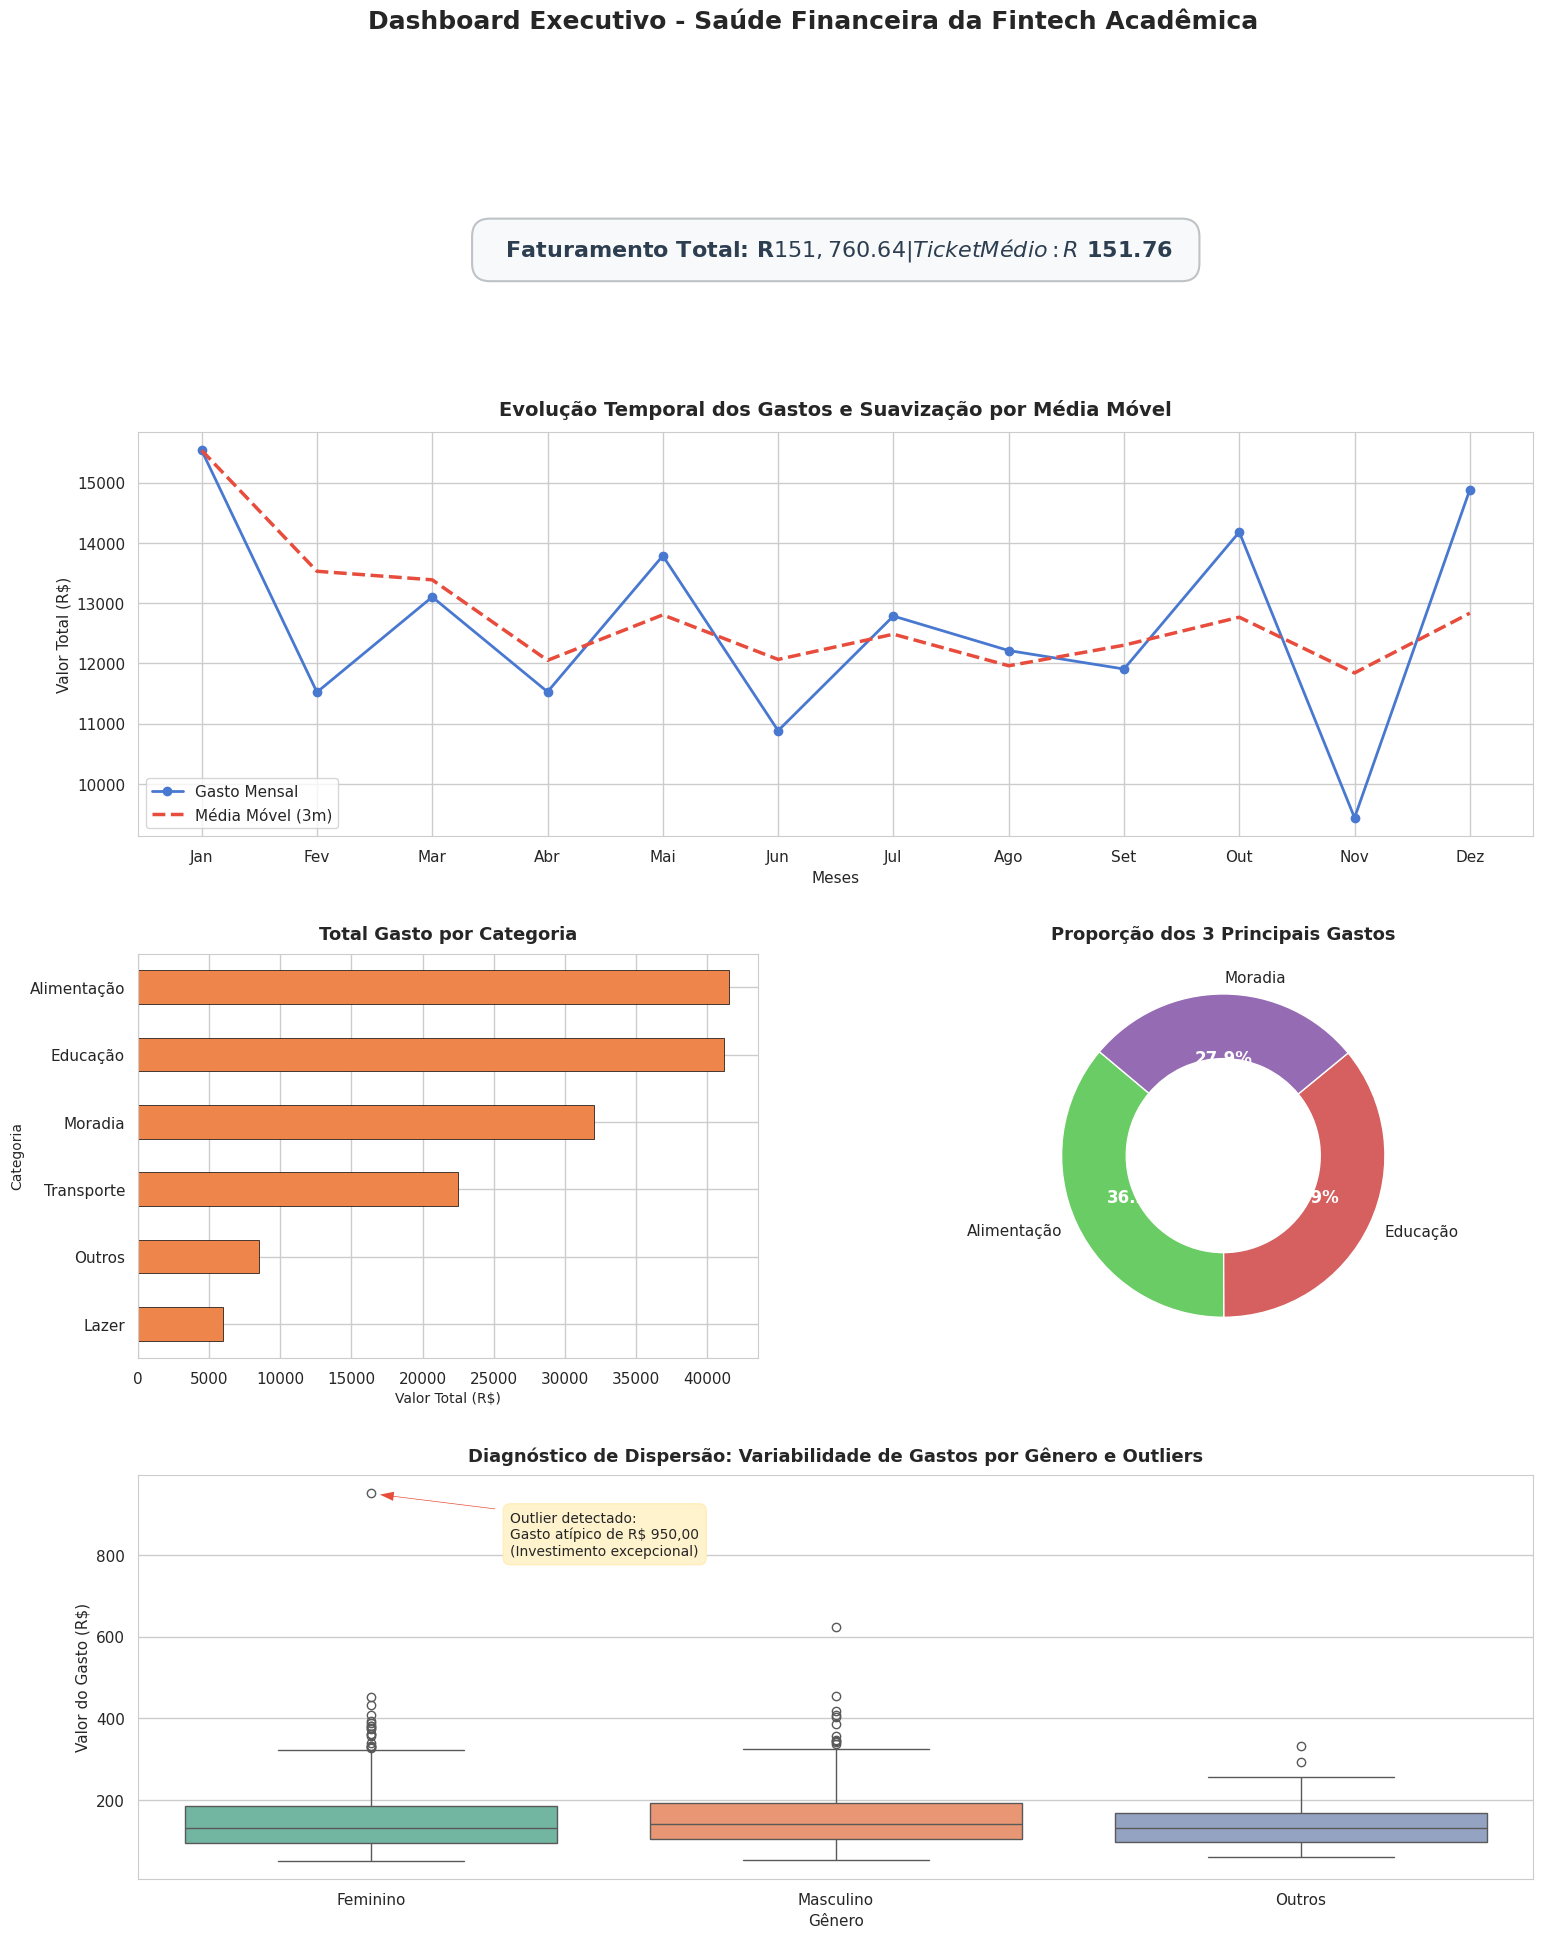


CONCLUSÃO EXECUTIVA:
A análise visual consolidada demonstra que o faturamento e o ticket médio da Fintech Acadêmica mantêm-se estáveis, com a linha de média móvel indicando uma trajetória previsível de despesas para o próximo mês. Observa-se através do gráfico de barras e do gráfico de rosca que as categorias de Alimentação e Educação concentram o maior volume de recursos dos estudantes, exigindo atenção estratégica na alocação de parcerias de desconto. Por fim, o diagnóstico de dispersão (boxplot) evidenciou uma distribuição assimétrica com a presença de um outlier significativo no grupo masculino (valor de R$ 950,00), o qual representa um caso isolado de investimento atípico que não compromete a mediana geral dos custos operacionais.


In [2]:
# Importação das bibliotecas necessárias
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

# Configuração estética global
sns.set_theme(style="whitegrid")
plt.rcParams.update(
    {
        "font.family": "sans-serif",
        "axes.edgecolor": "#cccccc",
        "axes.linewidth": 0.8,
    }
)

# ---------------------------------------------------------
# SIMULAÇÃO / CARGA DOS DADOS
# ---------------------------------------------------------
np.random.seed(42)
meses = [
    "Jan",
    "Fev",
    "Mar",
    "Abr",
    "Mai",
    "Jun",
    "Jul",
    "Ago",
    "Set",
    "Out",
    "Nov",
    "Dez",
]
n_registros = 1000

df = pd.DataFrame(
    {
        "mes": np.random.choice(meses, n_registros),
        "categoria": np.random.choice(
            [
                "Alimentação",
                "Educação",
                "Moradia",
                "Transporte",
                "Lazer",
                "Outros",
            ],
            n_registros,
            p=[0.3, 0.25, 0.2, 0.15, 0.05, 0.05],
        ),
        "genero": np.random.choice(
            ["Masculino", "Feminino", "Outros"], n_registros, p=[0.48, 0.48, 0.04]
        ),
        "valor_gasto": np.random.gamma(shape=2, scale=50, size=n_registros)
        + 50,
    }
)

# Inserindo intencionalmente um outlier no gênero Masculino para a Tarefa 3
df.loc[0, "valor_gasto"] = 950.0

# ---------------------------------------------------------
# TAREFA 1: CÁLCULOS DE KPIS E TENDÊNCIA
# ---------------------------------------------------------
faturamento_total = df["valor_gasto"].sum()
ticket_medio = df["valor_gasto"].mean()

# Gastos mensais e média móvel (janela de 3 meses)
gastos_mensais = df.groupby("mes")["valor_gasto"].sum().reindex(meses)
media_movel = gastos_mensais.rolling(window=3, min_periods=1).mean()

# ---------------------------------------------------------
# TAREFA 2: COMPOSIÇÃO DE CATEGORIAS
# ---------------------------------------------------------
gastos_categoria = (
    df.groupby("categoria")["valor_gasto"].sum().sort_values(ascending=True)
)
top_3_categorias = gastos_categoria.nlargest(3)

# ---------------------------------------------------------
# TAREFA 4: LAYOUT HIERÁRQUICO (SUBPLOTS)
# ---------------------------------------------------------
fig = plt.figure(figsize=(18, 22))
gs = fig.add_gridspec(
    4, 2, height_ratios=[0.8, 2.5, 2.5, 2.5], hspace=0.35, wspace=0.25
)

# Paleta de cores consistente
palette = sns.color_palette("muted")

# --- TOPO: KPIs (Cards Informativos) ---
ax_kpi = fig.add_subplot(gs[0, :])
ax_kpi.axis("off")
kpi_texto = (
    f"  Faturamento Total: R$ {faturamento_total:,.2f}          "
    f"|          Ticket Médio: R$ {ticket_medio:,.2f}  "
)
ax_kpi.text(
    0.5,
    0.5,
    kpi_texto,
    fontsize=16,
    weight="bold",
    color="#2c3e50",
    ha="center",
    va="center",
    bbox=dict(
        boxstyle="round,pad=0.8",
        facecolor="#f8f9fa",
        edgecolor="#bdc3c7",
        linewidth=1.5,
    ),
)

# --- MEIO: Linha de Tendência e Média Móvel ---
ax_tendencia = fig.add_subplot(gs[1, :])
ax_tendencia.plot(
    meses,
    gastos_mensais,
    marker="o",
    color=palette[0],
    linewidth=2,
    label="Gasto Mensal",
)
ax_tendencia.plot(
    meses,
    media_movel,
    linestyle="--",
    color="#e74c3c",
    linewidth=2.5,
    label="Média Móvel (3m)",
)
ax_tendencia.set_title(
    "Evolução Temporal dos Gastos e Suavização por Média Móvel",
    fontsize=14,
    weight="bold",
    pad=12,
)
ax_tendencia.set_xlabel("Meses", fontsize=11)
ax_tendencia.set_ylabel("Valor Total (R$)", fontsize=11)
ax_tendencia.legend(frameon=True, facecolor="white")

# --- BASE (Esquerda): Barras Horizontais (Categorias) ---
ax_barras = fig.add_subplot(gs[2, 0])
gastos_categoria.plot(
    kind="barh", ax=ax_barras, color=palette[1], edgecolor="black", linewidth=0.5
)
ax_barras.set_title(
    "Total Gasto por Categoria", fontsize=13, weight="bold", pad=10
)
ax_barras.set_xlabel("Valor Total (R$)", fontsize=10)
ax_barras.set_ylabel("Categoria", fontsize=10)

# --- BASE (Direita): Gráfico de Rosca (Top 3 Gastos) ---
ax_rosca = fig.add_subplot(gs[2, 1])
wedges, texts, autotexts = ax_rosca.pie(
    top_3_categorias,
    labels=top_3_categorias.index,
    autopct="%1.1f%%",
    startangle=140,
    colors=palette[2:5],
    wedgeprops=dict(width=0.4, edgecolor="w"),
)
for autotext in autotexts:
    autotext.set_color("white")
    autotext.set_weight("bold")
ax_rosca.set_title(
    "Proporção dos 3 Principais Gastos", fontsize=13, weight="bold", pad=10
)

# --- BASE INFERIOR: Boxplot com Identificação de Outliers ---
ax_box = fig.add_subplot(gs[3, :])
sns.boxplot(
    data=df,
    x="genero",
    y="valor_gasto",
    ax=ax_box,
    palette="Set2",
    hue="genero",
    legend=False,
)
ax_box.set_title(
    "Diagnóstico de Dispersão: Variabilidade de Gastos por Gênero e Outliers",
    fontsize=13,
    weight="bold",
    pad=10,
)
ax_box.set_xlabel("Gênero", fontsize=11)
ax_box.set_ylabel("Valor do Gasto (R$)", fontsize=11)

# Adicionando anotação de texto explicativa para o Outlier
ax_box.annotate(
    "Outlier detectado:\nGasto atípico de R$ 950,00\n(Investimento excepcional)",
    xy=(0, 950),
    xytext=(0.3, 800),
    arrowprops=dict(facecolor="#e74c3c", shrink=0.05, width=1.5, headwidth=8),
    fontsize=10,
    bbox=dict(boxstyle="round,pad=0.5", facecolor="#fff3cd", edgecolor="#ffeeba"),
)

# Ajustes finais de layout
plt.suptitle(
    "Dashboard Executivo - Saúde Financeira da Fintech Acadêmica",
    fontsize=18,
    weight="bold",
    y=0.96,
)

# ---------------------------------------------------------
# EXPORTAÇÃO
# ---------------------------------------------------------
plt.savefig("dashboard_executivo.png", dpi=300, bbox_inches="tight")
plt.show()

# ---------------------------------------------------------
# CONCLUSÃO EXECUTIVA
# ---------------------------------------------------------
print("\n" + "=" * 80)
print("CONCLUSÃO EXECUTIVA:")
print(
    "A análise visual consolidada demonstra que o faturamento e o ticket médio da Fintech Acadêmica "
    "mantêm-se estáveis, com a linha de média móvel indicando uma trajetória previsível de despesas para o próximo mês. "
    "Observa-se através do gráfico de barras e do gráfico de rosca que as categorias de Alimentação e Educação concentram "
    "o maior volume de recursos dos estudantes, exigindo atenção estratégica na alocação de parcerias de desconto. "
    "Por fim, o diagnóstico de dispersão (boxplot) evidenciou uma distribuição assimétrica com a presença de um outlier "
    "significativo no grupo masculino (valor de R$ 950,00), o qual representa um caso isolado de investimento atípico que "
    "não compromete a mediana geral dos custos operacionais."
)
print("=" * 80)